# Real-World Dataset Analysis: Diamonds Price Analysis

**Dataset:** Diamonds (~54,000 diamonds; carat, cut, color, clarity, dimensions, price) from the seaborn-data repository.

**Business question:** What drives the price of a diamond, and how do cut, colour, clarity and size interact?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
df=pd.read_csv(url)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 1. Explore the dataset

In [2]:
print(df.shape)
print(df.dtypes)
print('Missing:',df.isna().sum().sum(),'| Duplicates:',df.duplicated().sum())
print('Rows with zero x/y/z:',(df[['x','y','z']]==0).any(axis=1).sum())
df.describe().T

(53940, 10)
carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object
Missing: 0 | Duplicates: 146
Rows with zero x/y/z: 20


,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


## 2. Clean and preprocess
- Drop exact duplicate rows
- Zero in `x`, `y`, `z` is physically impossible, so treat as missing and impute with the median for the same carat decile
- Remove impossible records (`y`/`z` > 20 mm, depth outside 40-80, table > 90)
- Convert cut, colour and clarity to ordered categoricals

In [3]:
df=df.drop_duplicates()
df[['x','y','z']]=df[['x','y','z']].replace(0,np.nan)
df['cb']=pd.qcut(df['carat'],10,duplicates='drop')
for c in ['x','y','z']:
    df[c]=df[c].fillna(df.groupby('cb',observed=True)[c].transform('median'))
df=df.drop(columns='cb')
bad=(df.y>20)|(df.z>20)|(df.depth<40)|(df.depth>80)|(df.table>90)
print('Impossible rows removed:',bad.sum())
df=df[~bad].copy()
df['cut']=pd.Categorical(df.cut,['Fair','Good','Very Good','Premium','Ideal'],ordered=True)
df['color']=pd.Categorical(df.color,list('DEFGHIJ'),ordered=True)
df['clarity']=pd.Categorical(df.clarity,['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF'],ordered=True)
df['price_per_carat']=df.price/df.carat
df.shape

Impossible rows removed: 4


(53790, 11)

In [4]:
def iqr_outliers(s):
    q1,q3=s.quantile([.25,.75]); i=q3-q1
    return ((s<q1-1.5*i)|(s>q3+1.5*i)).sum()
pd.Series({c:iqr_outliers(df[c]) for c in ['carat','depth','table','price']})

carat    1872
depth    2524
table     603
price    3524
dtype: int64

Price, carat and depth have many IQR outliers, but they are genuine (large or high-end stones), so they are kept. Only physically impossible values were removed.

## 3. Exploratory data analysis

In [5]:
print('Skew price:',round(df.price.skew(),2),'| Skew log(price):',round(np.log(df.price).skew(),2))
print(df.groupby('cut',observed=True)[['price','carat']].mean().round(2))
print(df.groupby('color',observed=True).price.mean().round(0))
print(df.groupby('clarity',observed=True).price.mean().round(0))
df[['carat','depth','table','price','x','y','z']].corr().round(2)

Skew price: 1.62 | Skew log(price): 0.11
             price  carat
cut                      
Fair       4336.29   1.04
Good       3919.12   0.85
Very Good  3981.18   0.81
Premium    4582.95   0.89
Ideal      3462.81   0.70
color
D    3174.0
E    3080.0
F    3726.0
G    4001.0
H    4482.0
I    5082.0
J    5326.0
Name: price, dtype: float64
clarity
I1      3925.0
SI2     5057.0
SI1     3995.0
VS2     3928.0
VS1     3842.0
VVS2    3287.0
VVS1    2527.0
IF      2871.0
Name: price, dtype: float64


,carat,depth,table,price,x,y,z
carat,1.00,0.03,0.18,0.92,0.98,0.98,0.98
depth,0.03,1.00,-0.30,-0.01,-0.03,-0.03,0.10
table,0.18,-0.30,1.00,0.13,0.20,0.19,0.15
price,0.92,-0.01,0.13,1.00,0.89,0.89,0.88
x,0.98,-0.03,0.20,0.89,1.00,1.00,0.99
y,0.98,-0.03,0.19,0.89,1.00,1.00,0.99
z,0.98,0.10,0.15,0.88,0.99,0.99,1.00


## 4. Visualisations

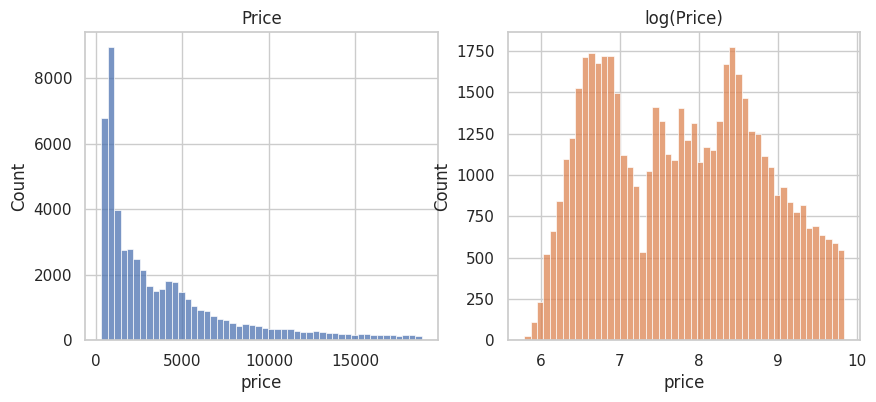

In [6]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.histplot(df.price,bins=50,ax=ax[0]); ax[0].set_title('Price')
sns.histplot(np.log(df.price),bins=50,ax=ax[1],color='C1'); ax[1].set_title('log(Price)')
plt.show()

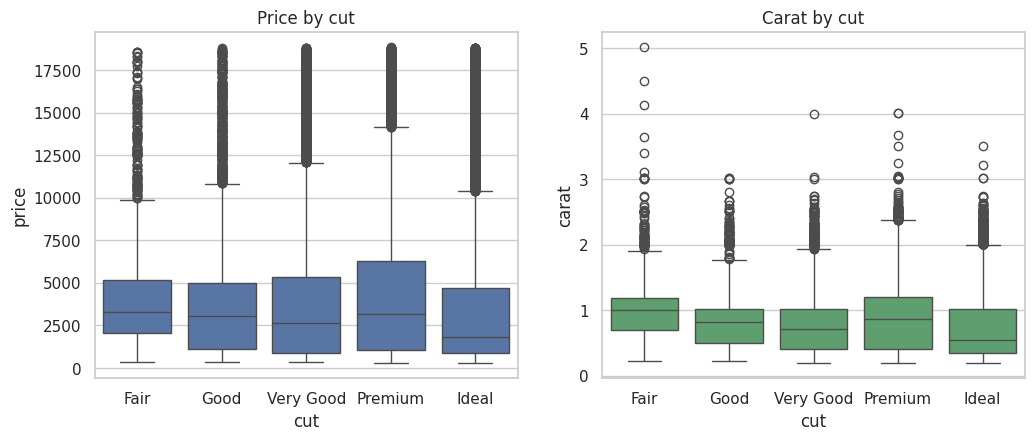

In [7]:
cut=['Fair','Good','Very Good','Premium','Ideal']
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
sns.boxplot(x='cut',y='price',data=df,order=cut,ax=ax[0]); ax[0].set_title('Price by cut')
sns.boxplot(x='cut',y='carat',data=df,order=cut,color='C2',ax=ax[1]); ax[1].set_title('Carat by cut')
plt.show()

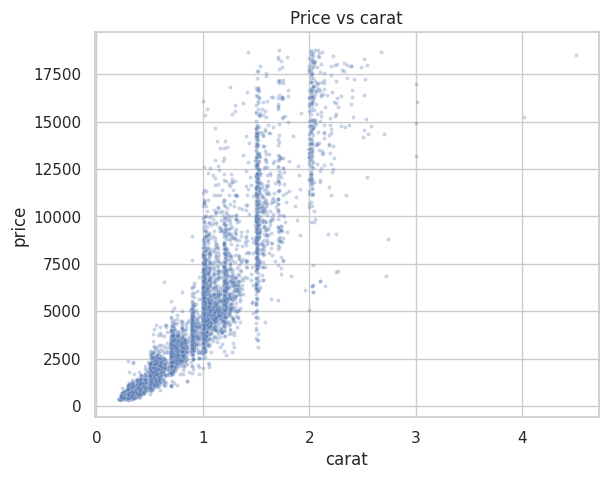

In [8]:
plt.figure(figsize=(6.5,5)); sns.scatterplot(x='carat',y='price',data=df.sample(8000,random_state=1),alpha=.3,s=8); plt.title('Price vs carat'); plt.show()

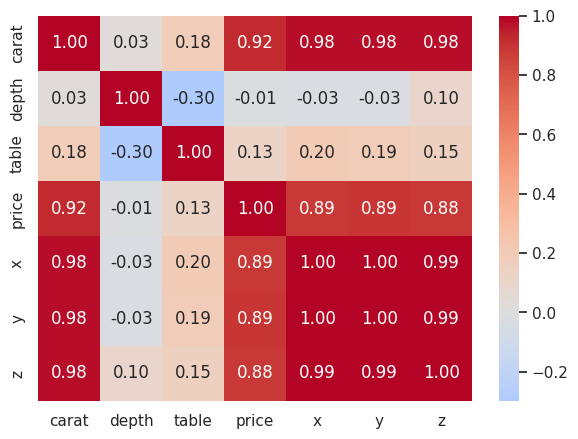

In [9]:
plt.figure(figsize=(7,5)); sns.heatmap(df[['carat','depth','table','price','x','y','z']].corr(),annot=True,fmt='.2f',cmap='coolwarm',center=0); plt.show()

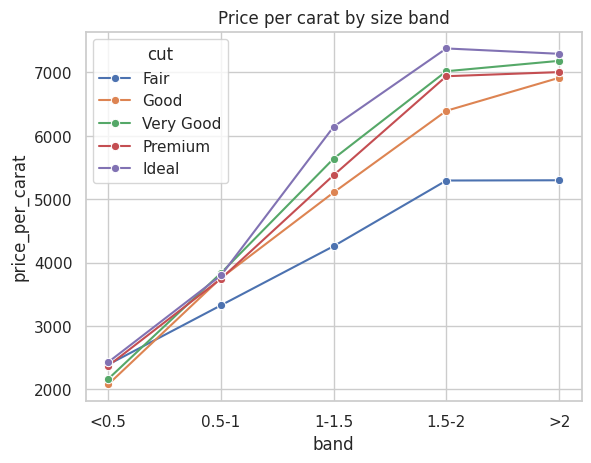

In [10]:
d=df.copy(); d['band']=pd.cut(d.carat,[0,.5,1,1.5,2,6],labels=['<0.5','0.5-1','1-1.5','1.5-2','>2'])
sns.lineplot(data=d,x='band',y='price_per_carat',hue='cut',hue_order=cut,errorbar=None,marker='o'); plt.title('Price per carat by size band'); plt.show()

## 5. Controlled comparison (log-log regression)
Because carat is a confounder, regress `log(price)` on `log(carat)` plus cut, colour and clarity.

In [11]:
X=pd.get_dummies(df[['cut','color','clarity']]).astype(float).drop(columns=['cut_Fair','color_D','clarity_I1'])
X['log_carat']=np.log(df.carat); X['const']=1.0
y=np.log(df.price)
b=np.linalg.lstsq(X.values,y.values,rcond=None)[0]
pred=X.values@b
print('R2 =',round(1-((y-pred)**2).sum()/((y-y.mean())**2).sum(),3))
pd.Series(b,X.columns).round(3)

R2 = 0.983


cut_Good         0.081
cut_Very Good    0.118
cut_Premium      0.140
cut_Ideal        0.162
color_E         -0.054
color_F         -0.095
color_G         -0.160
color_H         -0.251
color_I         -0.373
color_J         -0.511
clarity_SI2      0.428
clarity_SI1      0.592
clarity_VS2      0.741
clarity_VS1      0.812
clarity_VVS2     0.947
clarity_VVS1     1.018
clarity_IF       1.113
log_carat        1.884
const            7.857
dtype: float64

## 6. Key findings
1. Price is strongly right-skewed; a log transform makes it near-symmetric.
2. Carat is the dominant driver (r = 0.92 with price); each 1% increase in carat is associated with about 1.9% higher price.
3. Raw averages mislead: Ideal-cut diamonds have the lowest mean price (about 3,463) because they are smaller (mean 0.70 ct vs 1.04 ct for Fair).
4. After controlling for size, better cut, colour and clarity all raise price; clarity has the largest effect. The model explains about 98% of variance in log price.
5. Depth has almost no correlation with price (-0.01).

**Recommendations:** price and stock using carat first, then clarity and colour; do not read raw averages by cut as a measure of value; review the handful of records with impossible dimensions at the data-entry stage.